In [1]:
# --- POLITE repo-root bootstrap ---
import os, sys
from pathlib import Path
_p = Path.cwd()
for _c in (_p, *_p.parents):
    if (_c / 'caltools').is_dir():
        os.chdir(_c); break
_r = str(Path.cwd())
if _r not in sys.path:
    sys.path.insert(0, _r)
print('root:', _r)

root: /Users/blu3/PycharmProjects/POLITE


# QHY268M Detector Characterization — 2026-07-09

Salvage night (dead DEC, no tracking). Replicates the detector-characterization
steps of `reduction_20260302.ipynb` for the subset the frames support.

**Frames:** 25 BIAS (0 s), darks at 0.05/0.2/2/5 s (15/10/10/10). Pol/drift and the
failed night-sky super-flat are not detector-characterization data and are excluded.

**Measured:** read noise, bias/offset structure + stability, dark current (upper
limit), DSNU/FPN, thermal stability.

**Not measurable this night** (no flat field / no illumination series):
gain & unity gain (PTC), full-well capacity, linearity, PRNU. Single setpoint → no
dark-current-vs-temperature. Gain is a placeholder (1.0 e⁻/ADU); e⁻ values are ADU.

In [2]:
import glob, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import caltools as ct
os.makedirs('tmpimg', exist_ok=True)

GAIN_E_PER_ADU = 1.0   # placeholder — no PTC this night
D = 'FITSDATA/20260709/'

## Frame discovery

In [3]:
def grp(pat):
    return sorted(glob.glob(D + pat))

bias_files = grp('*_BIAS_*.fits')
dark_files = {
    0.05: grp('*_DARK_Dark_0.05s_*.fits'),
    0.2:  grp('*_DARK_Dark_0.2s_*.fits'),
    2.0:  grp('*_DARK_Dark_2s_*.fits'),
    5.0:  grp('*_DARK_Dark_5s_*.fits'),
}
print('bias:', len(bias_files))
for e, fs in dark_files.items():
    print(f'dark {e:>4}s:', len(fs))

config = ct.sensor_config_from_header(bias_files[0], gain=GAIN_E_PER_ADU)
roi = config.central_roi(height=2000, width=3000)
h0 = fits.getheader(bias_files[0])
print(f"gain setting {h0.get('GAIN')}, offset {h0.get('OFFSET')}, "
      f"set {h0.get('SET-TEMP')}C, bias CCD-TEMP {h0.get('CCD-TEMP')}C")

bias: 25
dark 0.05s: 15
dark  0.2s: 10
dark  2.0s: 10
dark  5.0s: 10
gain setting 0, offset 30, set -20.0C, bias CCD-TEMP -19.6C


## 1. Read noise (bias frame differencing)
$\sigma_\mathrm{read}=\sigma(B_{i+1}-B_i)/\sqrt2$ — removes fixed pattern, leaves temporal noise.

In [4]:
master_bias = ct.master_bias(bias_files, method='median')
bias_cube = ct.load_cube(bias_files)
read_noise_map_adu, temporal_std_map = ct.read_noise_map(bias_cube, method='frame_diff')
rn_result = ct.read_noise_spatial(read_noise_map_adu, config)
s = rn_result.scalar_summary
del bias_cube; gc.collect()
print(f"master bias: median {np.median(master_bias):.2f} ADU, mean {master_bias.mean():.2f}")
print(f"read noise:  {s['ron_rms_adu']:.3f} ADU RMS = {s['ron_rms_e']:.3f} e-, "
      f"median {s['ron_median_adu']:.3f} ADU, MAD-sigma {s['mad_sigma_adu']:.3f}")
print(f"hot px: >3sig {s['hot_3sig']:,}, >5sig {s['hot_5sig']:,}, >10sig {s['hot_10sig']:,}")

master bias: median 491.00 ADU, mean 497.01
read noise:  21.360 ADU RMS = 21.360 e-, median 5.625 ADU, MAD-sigma 1.046
hot px: >3sig 544,502, >5sig 233,329, >10sig 51,288


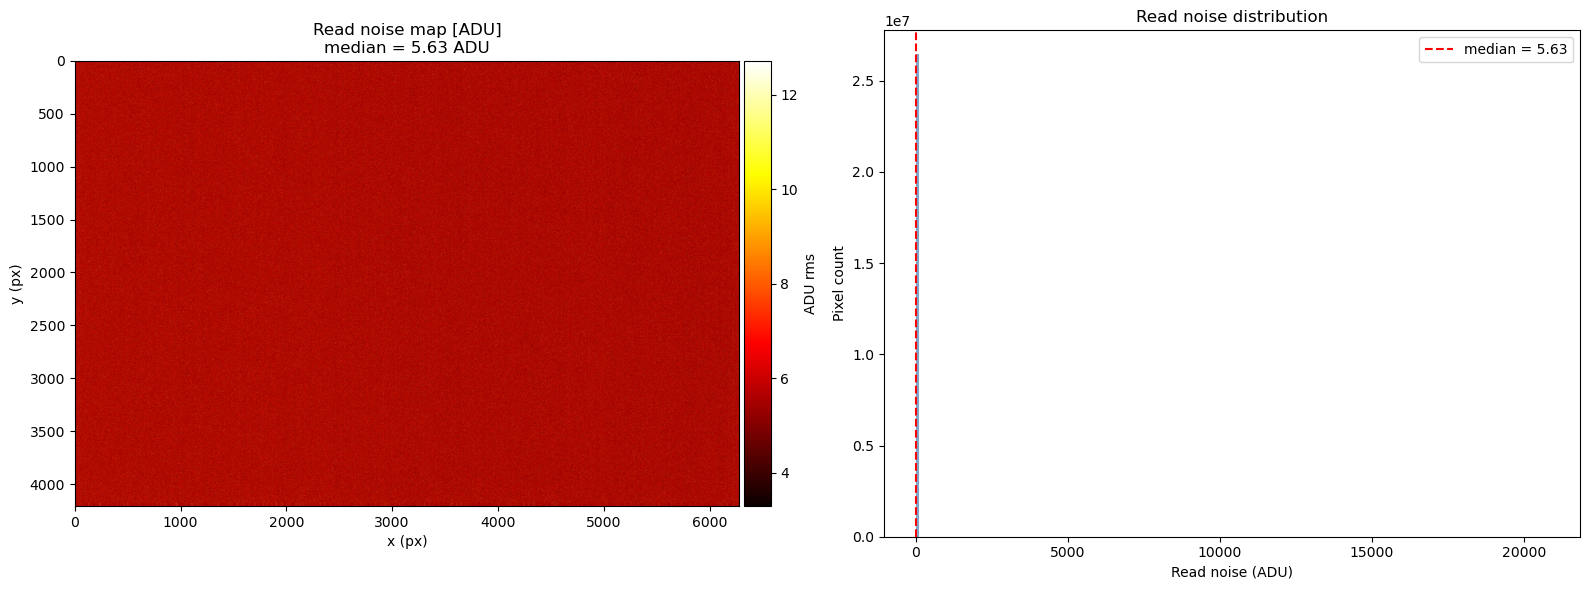

In [5]:
fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, read_noise_map_adu, label='Read noise', unit='ADU', cmap='hot')
plt.savefig('tmpimg/0709_read_noise_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bias / offset structure

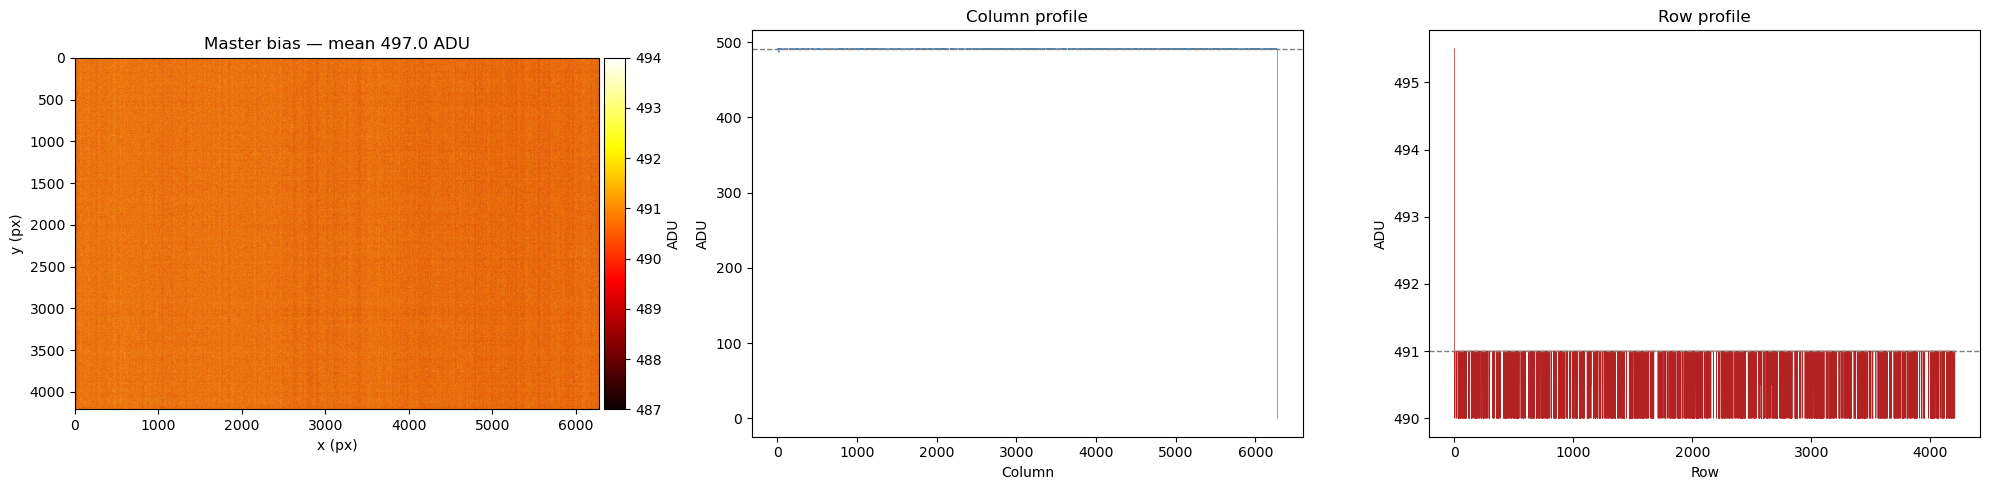

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ct.image_with_colorbar(axes[0], master_bias, label='ADU', cmap='hot', percentile_clip=(1, 99))
axes[0].set_title(f'Master bias — mean {master_bias.mean():.1f} ADU')
axes[1].plot(np.median(master_bias, axis=0), lw=0.5, color='steelblue')
axes[1].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[1].set_xlabel('Column'); axes[1].set_ylabel('ADU'); axes[1].set_title('Column profile')
axes[2].plot(np.median(master_bias, axis=1), lw=0.5, color='firebrick')
axes[2].axhline(np.median(master_bias), ls='--', color='gray', lw=1)
axes[2].set_xlabel('Row'); axes[2].set_ylabel('ADU'); axes[2].set_title('Row profile')
plt.tight_layout(); plt.savefig('tmpimg/0709_bias_structure.png', dpi=150, bbox_inches='tight'); plt.show()

### Bias temporal stability

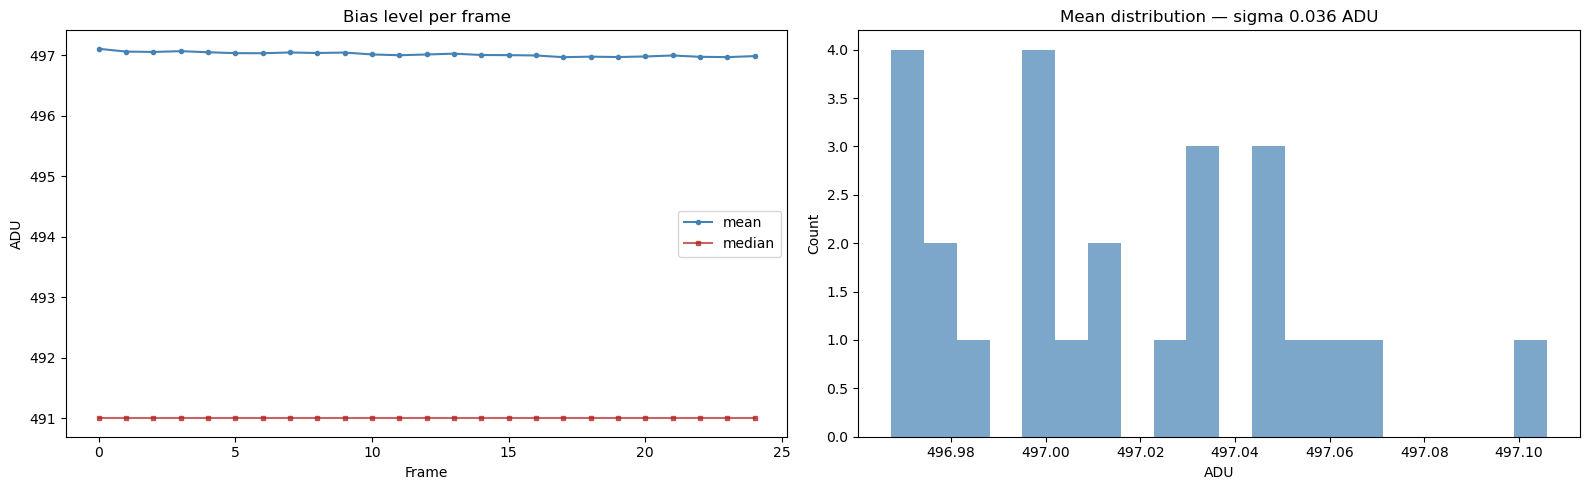

bias mean range 496.97 - 497.11 ADU, sigma 0.0357, MAD-sigma 0.0474


In [7]:
fmean = np.array([float(np.mean(ct.load_frame(f))) for f in bias_files])
fmed  = np.array([float(np.median(ct.load_frame(f))) for f in bias_files])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(fmean, 'o-', ms=3, color='steelblue', label='mean')
axes[0].plot(fmed, 's-', ms=3, color='firebrick', alpha=0.7, label='median')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('ADU'); axes[0].set_title('Bias level per frame'); axes[0].legend()
axes[1].hist(fmean, bins=20, color='steelblue', alpha=0.7)
axes[1].set_xlabel('ADU'); axes[1].set_ylabel('Count')
axes[1].set_title(f'Mean distribution — sigma {np.std(fmean):.3f} ADU')
plt.tight_layout(); plt.savefig('tmpimg/0709_bias_stability.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'bias mean range {fmean.min():.2f} - {fmean.max():.2f} ADU, sigma {np.std(fmean):.4f}, MAD-sigma {ct.mad_sigma(fmean):.4f}')

## 4. Dark current
**Upper limit only.** At ~-15C the bias-subtracted dark median is <=0.5 ADU even at 5 s
(at the noise floor), and bias was taken at -19.6C vs darks at ~-15.5C — a thermal
mismatch that biases the fit. Treat the slope as an upper bound, not a calibrated rate.

dark rate <= 0.16356 ADU/pix/s = 0.16356 e-/pix/s
offset -0.1212 ADU, R^2 0.9998


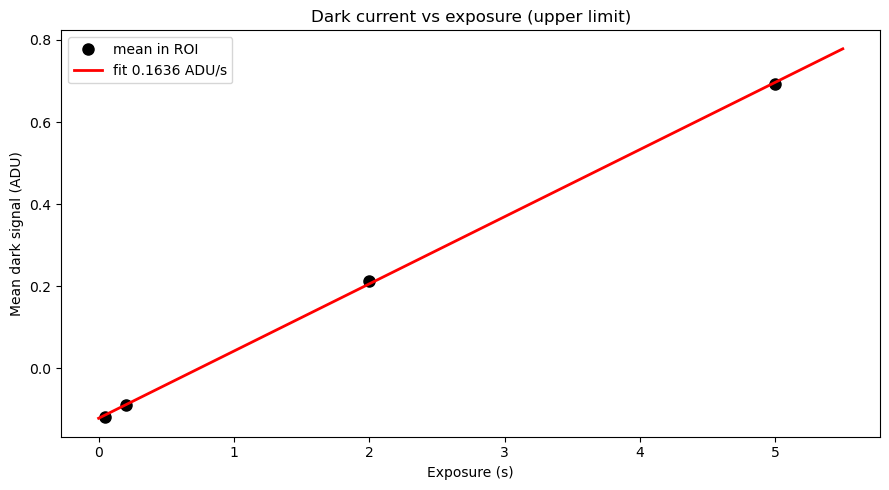

In [8]:
dc = ct.dark_current_vs_exposure(dark_files, master_bias, config, roi=roi)
ds = dc.scalar_summary
print(f"dark rate <= {ds['dark_rate_adu_per_s']:.5f} ADU/pix/s = {ds['dark_rate_e_per_s']:.5f} e-/pix/s")
print(f"offset {ds['offset_adu']:.4f} ADU, R^2 {ds['r_squared']:.4f}")
exptimes = dc.metadata['exptimes']; sig = dc.metadata['mean_signals_adu']
t = np.linspace(0, exptimes.max()*1.1, 100)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(exptimes, sig, 'ko', ms=8, label='mean in ROI')
ax.plot(t, np.polyval(dc.metadata['fit_coeffs'], t), 'r-', lw=2,
        label=f"fit {ds['dark_rate_adu_per_s']:.4f} ADU/s")
ax.set_xlabel('Exposure (s)'); ax.set_ylabel('Mean dark signal (ADU)')
ax.set_title('Dark current vs exposure (upper limit)'); ax.legend()
plt.tight_layout(); plt.savefig('tmpimg/0709_dark_current.png', dpi=150, bbox_inches='tight'); plt.show()

### Dark glow + warm pixels

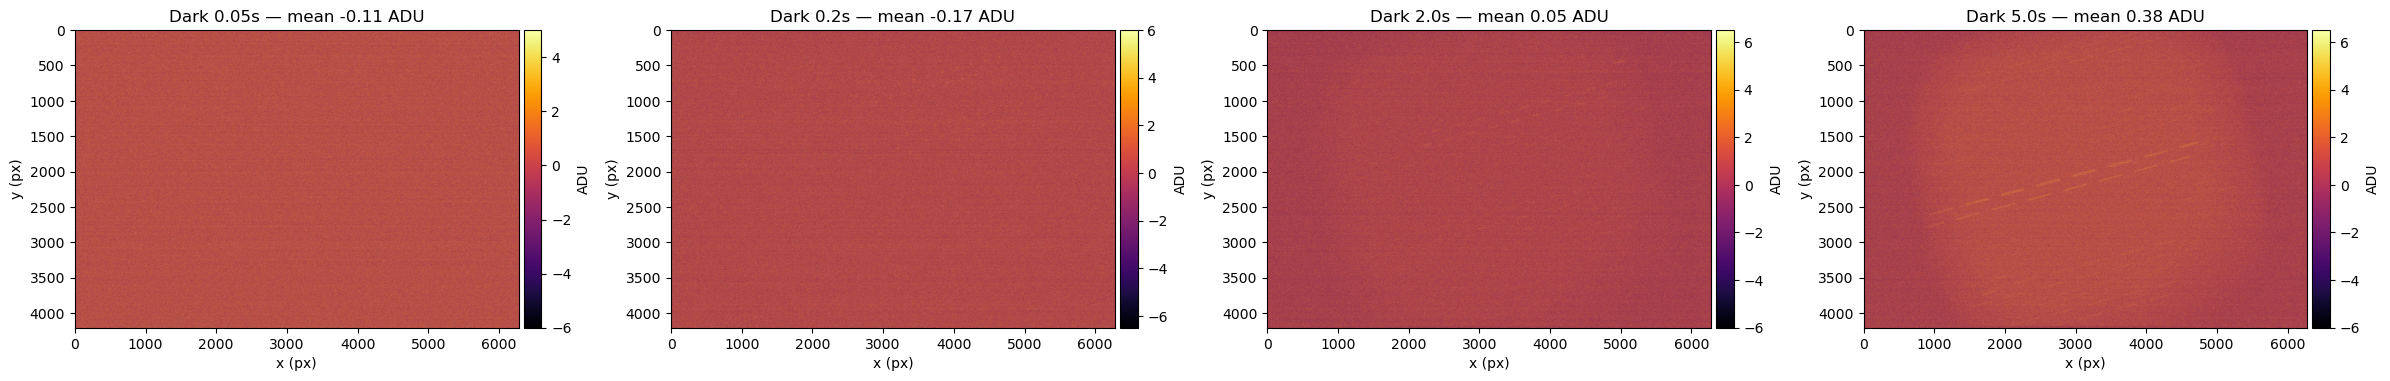

  0.05s: 181 warm px (0.0030%)
   0.2s: 434 warm px (0.0072%)
   2.0s: 583 warm px (0.0097%)
   5.0s: 665 warm px (0.0111%)


In [9]:
master_darks = {e: ct.master_dark(fs, master_bias) for e, fs in sorted(dark_files.items())}
glow = ct.dark_spatial_structure(master_darks, config)
n = len(master_darks)
fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
for ax, (e, md_) in zip(np.atleast_1d(axes), sorted(master_darks.items())):
    ct.image_with_colorbar(ax, md_, label='ADU', cmap='inferno', percentile_clip=(1, 99))
    ax.set_title(f'Dark {e}s — mean {np.mean(md_):.2f} ADU')
plt.tight_layout(); plt.savefig('tmpimg/0709_dark_glow.png', dpi=150, bbox_inches='tight'); plt.show()

warm = ct.warm_pixel_map(dark_files, master_bias, config, threshold_sigma=5.0, roi=roi)
ws = warm.scalar_summary
for e in sorted(dark_files):
    print(f"  {e:>4}s: {ws.get(f'n_warm_{e}s', 0):,.0f} warm px "
          f"({ws.get(f'frac_warm_{e}s', 0)*100:.4f}%)")

## 8. DSNU & fixed-pattern noise

DSNU (total / row / col / pixel, ADU):
  0.05s: 7.298  0.031  0.000  7.298
   0.2s: 9.753  0.183  0.039  9.740
   2.0s: 8.852  0.184  0.090  8.847
   5.0s: 8.528  0.216  0.244  8.521



FPN mean 0.8743 ADU (14.90% of temporal sigma), temporal sigma 5.8667, RON(diff) 5.9542 ADU


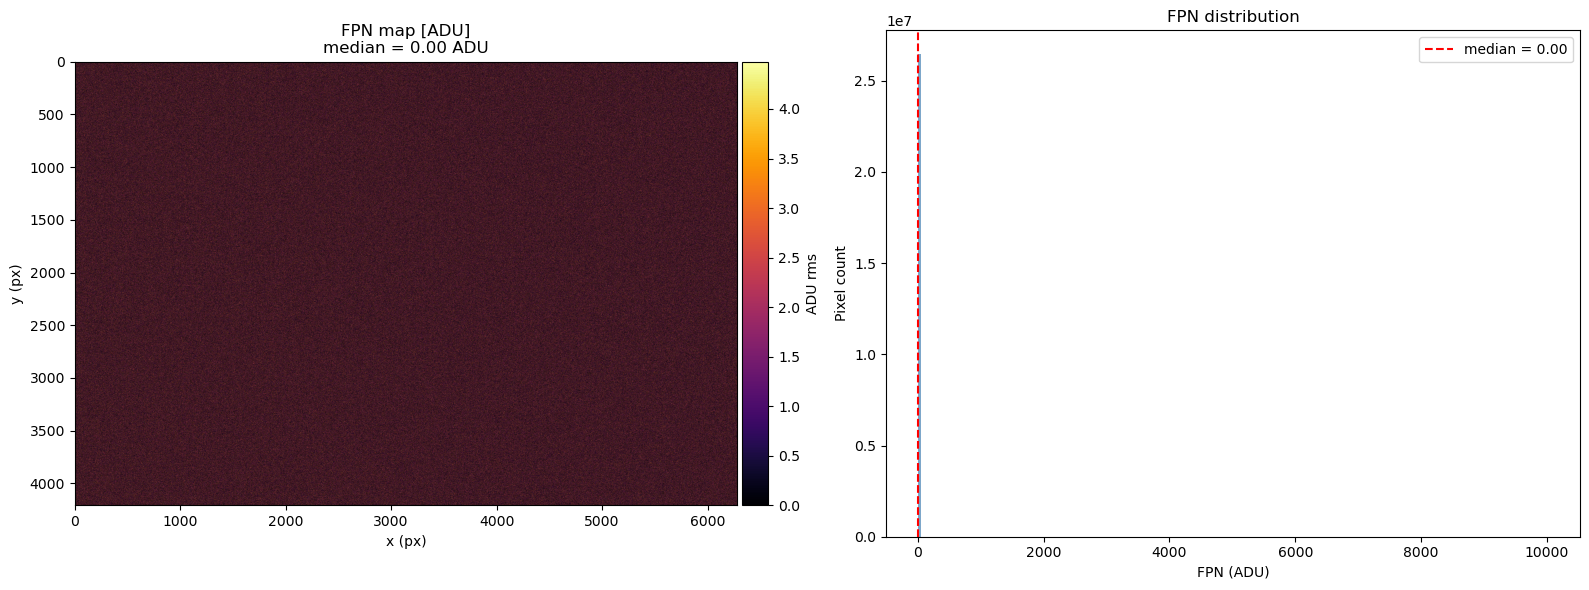

In [10]:
dsnu = ct.dsnu(master_darks, master_bias, config)
dd = dsnu.scalar_summary
print('DSNU (total / row / col / pixel, ADU):')
for e in sorted(master_darks):
    print(f"  {e:>4}s: {dd.get(f'dsnu_total_{e}s_adu',0):.3f}  {dd.get(f'dsnu_row_{e}s_adu',0):.3f}  "
          f"{dd.get(f'dsnu_col_{e}s_adu',0):.3f}  {dd.get(f'dsnu_pixel_{e}s_adu',0):.3f}")

fpn = ct.fpn(temporal_std_map, read_noise_map_adu)
fs_ = fpn.scalar_summary
print(f"\nFPN mean {fs_['fpn_mean_adu']:.4f} ADU ({fs_['fpn_fraction']*100:.2f}% of temporal sigma), "
      f"temporal sigma {fs_['temporal_std_mean_adu']:.4f}, RON(diff) {fs_['ron_mean_adu']:.4f} ADU")
fig = plt.figure(figsize=(16, 6))
ct.noise_map_with_histogram(fig, fpn.maps['fpn_map'], label='FPN', unit='ADU', cmap='inferno')
plt.savefig('tmpimg/0709_fpn_map.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Thermal & timing stability
DATE-OBS is corrupt (year 1996) on many frames — the pre-fix GPS-header misparse on
this GPS-less camera. Timing cadence is reported only for frames with a sane 2026
timestamp; CCD-TEMP is unaffected.

48/70 frames with sane 2026 DATE-OBS; cadence not reported (corruption makes it unreliable)


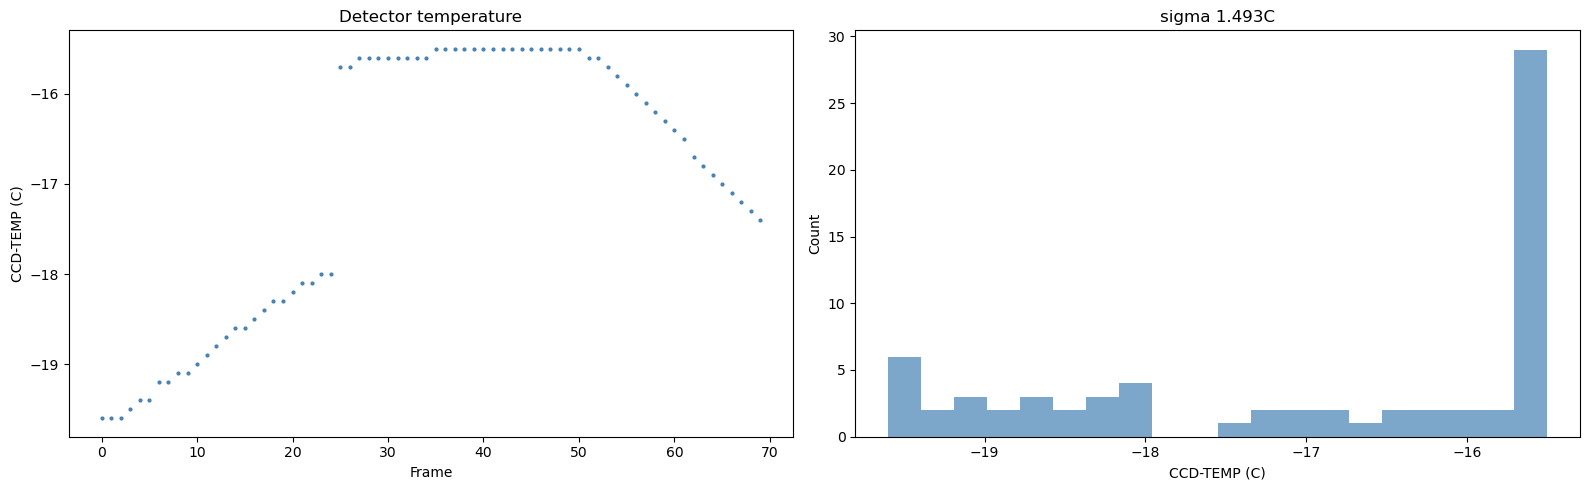

temp range -19.60 - -15.50C, sigma 1.493, MAD-sigma 1.260


In [11]:
all_files = bias_files + [f for fs in dark_files.values() for f in fs]
ts = ct.get_timestamps(sorted(all_files))
yrs = ts.astype('datetime64[Y]').astype(int) + 1970
good = ts[(yrs == 2026) & ~np.isnat(ts)]
print(f'{len(good)}/{len(all_files)} frames with sane 2026 DATE-OBS; '
      'cadence not reported (corruption makes it unreliable)')

temps = np.array([fits.getheader(f)['CCD-TEMP'] for f in all_files])
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(temps, 'o', ms=2, color='steelblue')
axes[0].set_xlabel('Frame'); axes[0].set_ylabel('CCD-TEMP (C)'); axes[0].set_title('Detector temperature')
axes[1].hist(temps, bins=20, color='steelblue', alpha=0.7)
axes[1].set_xlabel('CCD-TEMP (C)'); axes[1].set_ylabel('Count')
axes[1].set_title(f'sigma {np.std(temps):.3f}C')
plt.tight_layout(); plt.savefig('tmpimg/0709_temp_stability.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'temp range {temps.min():.2f} - {temps.max():.2f}C, sigma {np.std(temps):.3f}, MAD-sigma {ct.mad_sigma(temps):.3f}')

## Summary

In [12]:
print('QHY268M 2026-07-09 — detector characterization')
print('='*60)
print(f"gain setting        : {h0.get('GAIN')} (offset {h0.get('OFFSET')})")
print(f"master bias         : {np.median(master_bias):.2f} ADU")
print(f"read noise          : {s['ron_median_adu']:.3f} ADU (robust median; RMS {s['ron_rms_adu']:.1f} outlier-inflated)")
print(f"bias stability sigma: {np.std(fmean):.4f} ADU")
print(f"dark current        : <= {ds['dark_rate_adu_per_s']:.5f} ADU/s (upper limit)")
print(f"FPN                 : {fs_['fpn_mean_adu']:.4f} ADU ({fs_['fpn_fraction']*100:.1f}% of temporal)")
print(f"temp stability sigma: {np.std(temps):.3f} C")
print('='*60)
print('not measurable (no flat / illumination series):')
print('  gain & unity gain (PTC), full-well capacity, linearity, PRNU,')
print('  dark current vs temperature (single setpoint)')

QHY268M 2026-07-09 — detector characterization
gain setting        : 0 (offset 30)
master bias         : 491.00 ADU
read noise          : 5.625 ADU (robust median; RMS 21.4 outlier-inflated)
bias stability sigma: 0.0357 ADU
dark current        : <= 0.16356 ADU/s (upper limit)
FPN                 : 0.8743 ADU (14.9% of temporal)
temp stability sigma: 1.493 C
not measurable (no flat / illumination series):
  gain & unity gain (PTC), full-well capacity, linearity, PRNU,
  dark current vs temperature (single setpoint)
